In [9]:
%matplotlib inline

In [1]:
%matplotlib widget

In [2]:
%matplotlib ipympl
import matplotlib.pyplot as plt

In [3]:
from qclib import by_date
from ipywidgets import widgets

In [4]:
import xarray as xr
import pandas as pd

## define load and plot functions

In [5]:
def path2date(path2file):
    """
    Takes path to file and converts to date. Needs adjustment for individual
    circumstances.
    """
    return pd.to_datetime(path2file.name.split('.')[-2])


def read_data(path2file):
    """
    Takes the path to the file and returns an object that the
    plot function can turn into a plot. Needs ajustment for individual
    circumstances"""
    ds = xr.open_dataset(path2file)
    return ds


def plot_data(data_object, a):
    ds = data_object['bla']
    apply_mask_clear_sky = True
    apply_mask_clear_sky = True
    dssel = ds
    show_clearsky = True
    
    dssel.down_short_hemisp.plot(ax = a, label = 'global_horizontal')
    if apply_mask_clear_sky:
        g = a.get_lines()[-1]
        col = g.get_color()
        g.set_alpha(0.5)
        g.set_label('_nolegend_')
        dssel.down_short_hemisp.where(dssel.mask_clear_sky_shortwave_radflux).plot(ax = a, label = 'global_horizontal', color = col)
    dssel.down_short_diffuse_hemisp.plot(ax = a, label = 'diffuse_horizontal')
    if apply_mask_clear_sky:
        g = a.get_lines()[-1]
        col = g.get_color()
        g.set_alpha(0.5)
        g.set_label('_nolegend_')
        dssel.down_short_diffuse_hemisp.where(dssel.mask_clear_sky_shortwave_radflux).plot(ax = a, label = 'diffuse_horizontal', color = col)
    
    if show_clearsky:
        dssel.down_short_hemisp_clearsky.plot(ax = a, ls = '--', label = 'clearsky_global_horizontal')
        dssel.down_short_diffuse_hemisp_clearsky.plot(ax = a, ls = '--', label = 'clearsky_diffuse_horizontal')
    a.legend(loc = 2)
    a.set_ylabel('Irradiance')

# create instance

In [6]:
reload(by_date)
# reload(quicklooks)

<module 'qclib.by_date' from '/Users/htelg/prog/qclib/qclib/by_date.py'>

In [7]:
pattern = '*.nc'
p2fld = pl.Path('/Volumes/stu3data2/bnf_radsys_data/bnfradsys43m60sS10.c1/0.2/')

In [8]:
# test path2date and read_data
path2file = next(p2fld.glob(pattern))
bla = read_data(path2file)
path2date(path2file)

Timestamp('2025-12-02 00:00:00')

In [9]:
data = by_date.Data(path2datafolder=[
    ['bla', p2fld, read_data, path2date, pattern]
], plot_function={'bla': plot_data, })

### test and develop plot function

In [10]:
data_object = data.active_data

In [14]:
%matplotlib widget

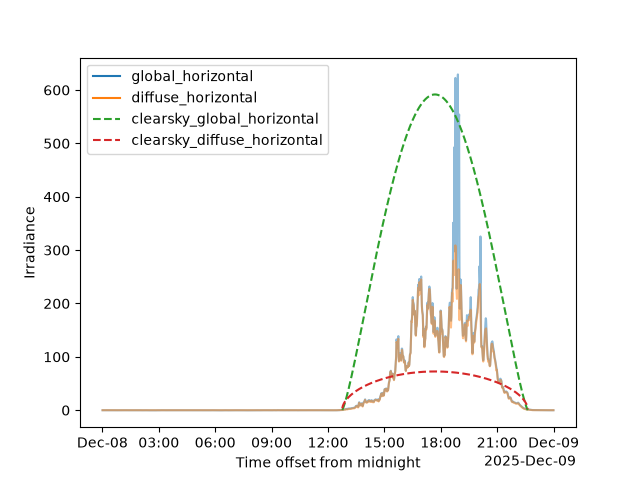

In [15]:
# %matplotlib widget
# f,a  = plt.subplots()
out = data.plot()


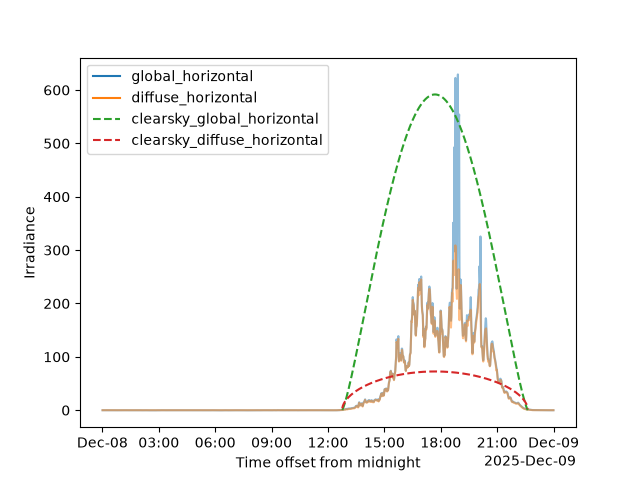

In [13]:
plt.gcf().show()

In [36]:
a = data_object['bla'].down_short_hemisp.to_pandas().plot()
f = a.get_figure()
f.show()

In [27]:
plt.gcf().show()

### do it

In [18]:
cont = by_date.Controller(data = data,#Data('/mnt/telg/data/grad/surfrad/aod1625/0.4/tbl/2020/', read_data, plot_data),                        
                        # path2database=path2database,
                        # database_table_name_base='vis_nsascience_quicklooks',
                         )

In [19]:
cont.view.controlls.initiate()

date picker changed to 2025-12-08 00:00:00


[<Axes: xlabel='Time offset from midnight', ylabel='Irradiance'>]

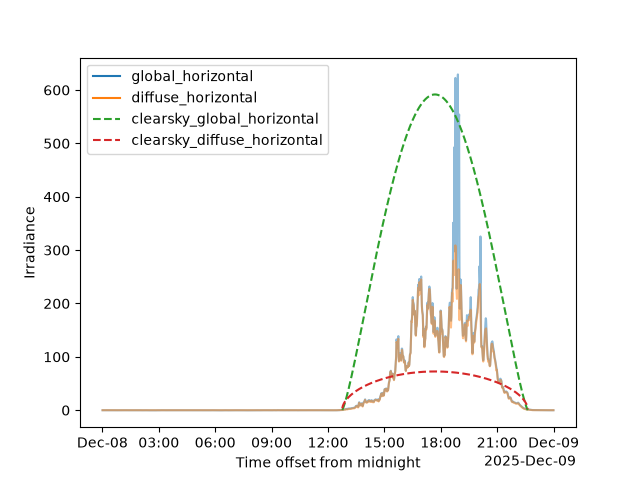

In [45]:
cont.view.plot.initiate()

In [20]:
cont.view.controlls.date_picker.value

Timestamp('2025-12-08 00:00:00')

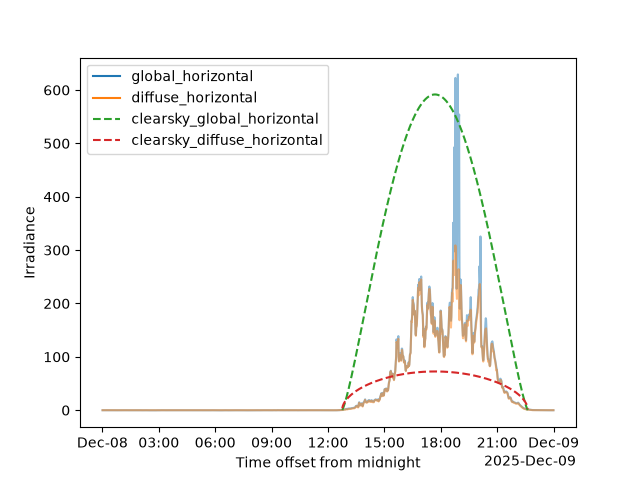

In [46]:
plt.gcf().show()

Python: /Users/htelg/miniconda3/envs/py13/bin/python
Matplotlib: 3.11.0
Backend: widget


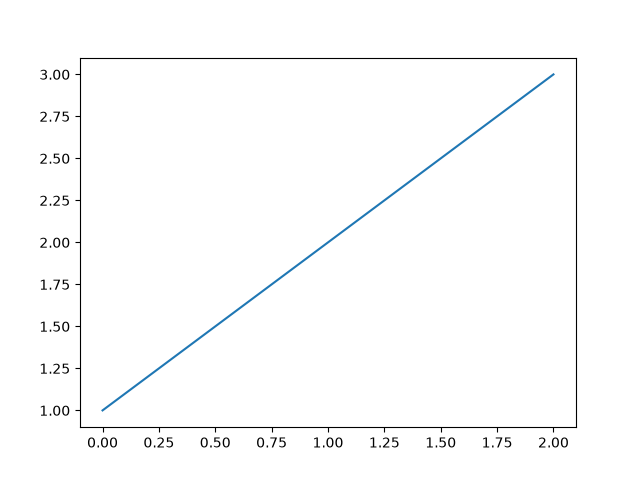

In [15]:
%matplotlib widget

import sys
import matplotlib
import matplotlib.pyplot as plt

print("Python:", sys.executable)
print("Matplotlib:", matplotlib.__version__)
print("Backend:", matplotlib.get_backend())

fig, ax = plt.subplots()
ax.plot([1, 2, 3])

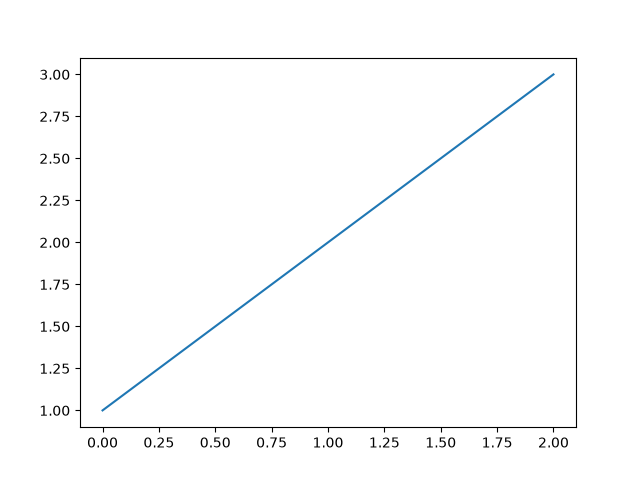

In [19]:
fig, ax = plt.subplots()
ax.plot([1, 2, 3])

In [20]:
import ipywidgets as widgets
from IPython.display import display

display(widgets.IntSlider(description="Test"))

IntSlider(value=0, description='Test')

In [21]:
w = widgets.IntSlider()

bundle = w._repr_mimebundle_()
print(bundle.keys())
print(bundle.get("application/vnd.jupyter.widget-view+json"))

dict_keys(['text/plain', 'application/vnd.jupyter.widget-view+json'])
{'version_major': 2, 'version_minor': 0, 'model_id': 'f0337d17f7794822810cb9ddfeb2d415'}
